<a href="https://colab.research.google.com/github/harini-3005/Oasis-Infobyte-task-4/blob/main/task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving apps.csv to apps.csv
   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3           3                              Sketch - Draw & Paint   
4           4              Pixel Draw - Number Art Coloring Book   

         Category  Rating  Reviews  Size     Installs  Type Price  \
0  ART_AND_DESIGN     4.1      159   19M      10,000+  Free     0   
1  ART_AND_DESIGN     3.9      967   14M     500,000+  Free     0   
2  ART_AND_DESIGN     4.7    87510  8.7M   5,000,000+  Free     0   
3  ART_AND_DESIGN     4.5   215644   25M  50,000,000+  Free     0   
4  ART_AND_DESIGN     4.3      967  2.8M     100,000+  Free     0   

  Content Rating                     Genres      Last Updated  \
0       Everyone               Art & Design   January 7, 2018   
1       Everyone  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


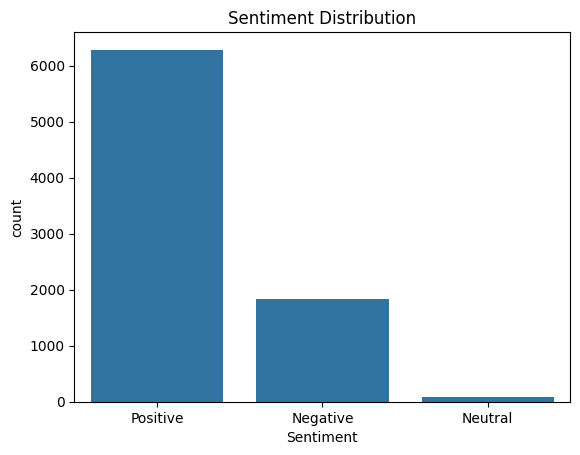

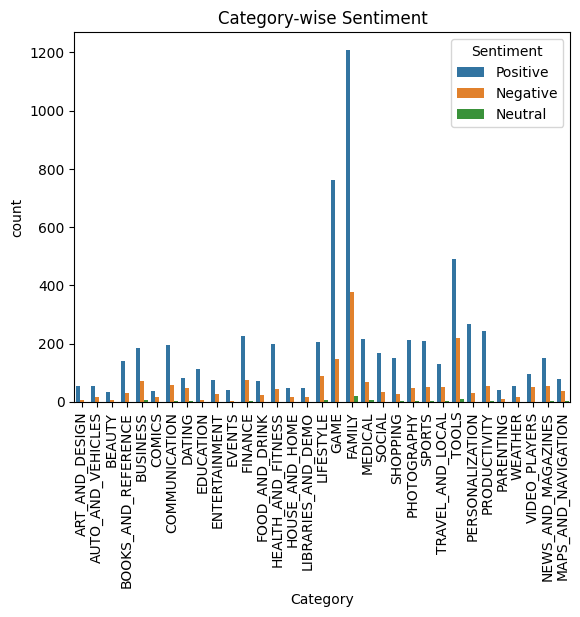


Sentiment Analysis Completed Successfully!


In [ ]:
# =====================================
# SENTIMENT ANALYSIS ON APP DATA
# =====================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# 2. Upload Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

# 3. Basic Exploration
print(df.head())
print(df.isnull().sum())

# =====================================
# 🧹 DATA CLEANING
# =====================================

# Drop missing ratings
df = df.dropna(subset=['Rating'])

# Convert Rating to Sentiment
def sentiment_label(r):
    if r >= 4:
        return "Positive"
    elif r == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Rating'].apply(sentiment_label)

# Create text feature (use App + Category as proxy text)
df['Text'] = df['App'] + " " + df['Category'] + " " + df['Genres']

# =====================================
# NLP FEATURE ENGINEERING
# =====================================

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['Text'])
y = df['Sentiment']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================
# 🤖 MODEL BUILDING
# =====================================

model = MultinomialNB()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# =====================================
# 📊 VISUALIZATION
# =====================================

# Sentiment Distribution
plt.figure()
sns.countplot(x=df['Sentiment'])
plt.title("Sentiment Distribution")
plt.show()

# Category Sentiment
plt.figure()
sns.countplot(data=df, x='Category', hue='Sentiment')
plt.xticks(rotation=90)
plt.title("Category-wise Sentiment")
plt.show()

print("\nSentiment Analysis Completed Successfully!")
